**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data
url = "https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv"
df = pd.read_csv(url)

# Fix column name
df = df.rename(columns={"Neighbourhood ": "Neighborhood"})

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

    Neighborhood       Price  Review Scores Rating
2      Manhattan  183.664286             91.801496
4  Staten Island  146.166667             90.843750
1       Brooklyn  127.747378             92.363497
3         Queens   96.857233             91.549057
0          Bronx   75.276498             91.654378


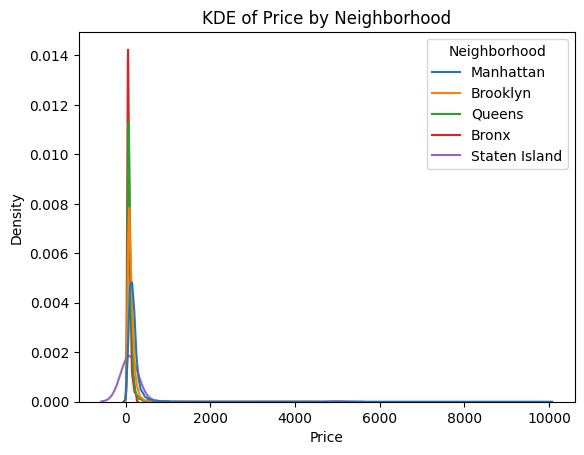

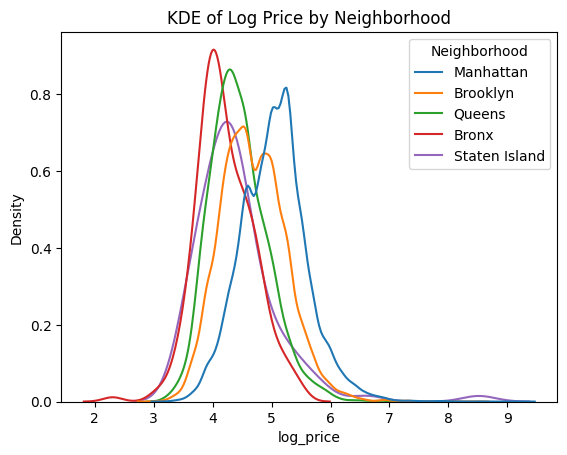

In [2]:
# Compute average price and review score by neighborhood
grouped = df.groupby("Neighborhood").agg({
    "Price": "mean",
    "Review Scores Rating": "mean"
}).reset_index()

# Print sorted results to identify most expensive borough
print(grouped.sort_values(by="Price", ascending=False))

# Manhattan is the most expensive borough on average.

# KDE plot of price
plt.figure()
sns.kdeplot(data=df, x="Price", hue="Neighborhood", common_norm=False)
plt.title("KDE of Price by Neighborhood")
plt.show()

# Create log price (reduce skewness)
df["log_price"] = np.log(df["Price"])

# KDE plot of log price
plt.figure()
sns.kdeplot(data=df, x="log_price", hue="Neighborhood", common_norm=False)
plt.title("KDE of Log Price by Neighborhood")
plt.show()

2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [3]:
# Create dummy variables for Neighborhood
dummies = pd.get_dummies(df["Neighborhood"])

# Define X (predictors) and y (target)
X = dummies
y = df["Price"]

# Fit linear regression without an intercept
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Print coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients)

# The regression coefficients are equal to the average prices from part 1 for each neighborhood.
# In a regression of a continuous variable on one categorical variable, the coefficients are equal to the group means of the dependent variable for each category.

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [4]:
# Create dummy variables and drop one category (baseline)
dummies = pd.get_dummies(df["Neighborhood"], drop_first=True)

# Define X and y
X = dummies
y = df["Price"]

# Fit linear regression with an intercept
model = LinearRegression()
model.fit(X, y)

# Print intercept
print("Intercept:", model.intercept_)

# Print coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients)

# You must handle the creation of the dummies differently by dropping one category to avoid multicollinearity.
# The intercept is 75.2765, representative of the average price in the Bronx.
# Each coefficient represents the difference in average price between that neighborhood and the baseline (Bronx).
# You can get the coefficients in part 2 from these new coefficients by adding each coefficient to the intercept.

Intercept: 75.27649769585331
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [5]:
# Create dummy variables for Neighborhood
dummies = pd.get_dummies(df["Neighborhood"], drop_first=True).astype(int)

# Combine predictors: Review Score + Neighborhood dummies
X = pd.concat([df["Review Scores Rating"], dummies], axis=1)

y = df["Price"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Compute metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print results
print("Test R^2:", r2)
print("Test RMSE:", rmse)

# Print coefficients
print("Coefficients:")
print(pd.Series(model.coef_, index=X.columns))

# The R^2 is 0.0459, and the RMSE is 140.92.
# The coefficient on Review Scores Rating is 1.2119.
# There is no information on property type, but Manhattan has the highest coefficient so the property would presumably be in Manhattan.

Test R^2: 0.045925883817350965
Test RMSE: 140.91821103729345
Coefficients:
Review Scores Rating      1.211852
Brooklyn                 51.555970
Manhattan               107.413553
Queens                   20.198573
Staten Island            23.454672
dtype: float64


5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [6]:
# Create dummy variables for Neighborhood and Property Type
neigh_dummies = pd.get_dummies(df["Neighborhood"], drop_first=True).astype(int)
prop_dummies = pd.get_dummies(df["Property Type"], drop_first=True).astype(int)

# Combine predictors: Review Score + both sets of dummies
X = pd.concat([df["Review Scores Rating"], neigh_dummies, prop_dummies], axis=1)

y = df["Price"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Compute metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print results
print("Test R^2:", r2)
print("Test RMSE:", rmse)

# Print coefficients
print("Coefficients:")
print(pd.Series(model.coef_, index=X.columns))

# The R^2 is 0.0542, and the RMSE is 140.30.
# The coefficient on Review Scores Rating is 1.2010.
# The most expensive kind of property you can rent, relative to the baseline property type, is a bungalow.

Test R^2: 0.054242713551245325
Test RMSE: 140.30266238276283
Coefficients:
Review Scores Rating      1.201011
Brooklyn                 59.633702
Manhattan               121.005520
Queens                   26.830617
Staten Island            15.700974
Bed & Breakfast         -28.703920
Boat                     47.070419
Bungalow                 83.972440
Cabin                    12.389621
Camper/RV               -13.817125
Castle                  -41.810548
Chalet                  -30.237720
Condominium              61.907162
Dorm                    -42.277758
House                    34.711346
Hut                    -134.604484
Lighthouse              -91.438731
Loft                     69.891025
Other                    49.249761
Townhouse                44.110768
Treehouse                10.325182
Villa                    33.901468
dtype: float64


6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient changes from part 4 to 5 because I controlled for an additional variable (Property Type). In part 4, the coefficient measures the effect of ratings on price as only Neighborhood is held constant, whereas part 5 measures the effect of holding both Neighborhood and Property Type constant. The meaning changes to the effect of a one-point increase in rating on price for listings in the same neighborhood AND of the same property type.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?